In [1]:
import sys
import numpy as np
import pandas as pd
import torch

from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

c:\Users\Ammulu\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0819 07:44:14.981000 16932 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Python: c:\Users\Ammulu\AppData\Local\Programs\Python\Python310\python.exe
PyTorch: 2.11.0+cpu
CUDA available: False


In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "liar"

print("Project root:", PROJECT_ROOT)
print("Dataset folder:", DATA_DIR)
print("Dataset exists:", DATA_DIR.exists())

Project root: d:\TruthLensAI
Dataset folder: d:\TruthLensAI\data\liar
Dataset exists: True


In [3]:
columns = [
    "id",
    "label",
    "statement",
    "subject",
    "speaker",
    "job_title",
    "state_info",
    "party_affiliation",
    "barely_true_counts",
    "false_counts",
    "half_true_counts",
    "mostly_true_counts",
    "pants_on_fire_counts",
    "context"
]

train_df = pd.read_csv(
    DATA_DIR / "train.tsv",
    sep="\t",
    header=None,
    names=columns
)

valid_df = pd.read_csv(
    DATA_DIR / "valid.tsv",
    sep="\t",
    header=None,
    names=columns
)

test_df = pd.read_csv(
    DATA_DIR / "test.tsv",
    sep="\t",
    header=None,
    names=columns
)

print("Train shape:", train_df.shape)
print("Validation shape:", valid_df.shape)
print("Test shape:", test_df.shape)

Train shape: (10240, 14)
Validation shape: (1284, 14)
Test shape: (1267, 14)


In [4]:
print("Training labels:")
print(train_df["label"].value_counts())

print("\nValidation labels:")
print(valid_df["label"].value_counts())

print("\nTest labels:")
print(test_df["label"].value_counts())

Training labels:
label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64

Validation labels:
label
false          263
mostly-true    251
half-true      248
barely-true    237
true           169
pants-fire     116
Name: count, dtype: int64

Test labels:
label
half-true      265
false          249
mostly-true    241
barely-true    212
true           208
pants-fire      92
Name: count, dtype: int64


In [5]:
label_names = [
    "pants-fire",
    "false",
    "barely-true",
    "half-true",
    "mostly-true",
    "true"
]

label2id = {
    label: i
    for i, label in enumerate(label_names)
}

id2label = {
    i: label
    for i, label in enumerate(label_names)
}

print("label2id:", label2id)
print("id2label:", id2label)

label2id: {'pants-fire': 0, 'false': 1, 'barely-true': 2, 'half-true': 3, 'mostly-true': 4, 'true': 5}
id2label: {0: 'pants-fire', 1: 'false', 2: 'barely-true', 3: 'half-true', 4: 'mostly-true', 5: 'true'}


In [6]:
train_df["label_id"] = train_df["label"].map(label2id)
valid_df["label_id"] = valid_df["label"].map(label2id)
test_df["label_id"] = test_df["label"].map(label2id)

print("Missing train labels:", train_df["label_id"].isna().sum())
print("Missing validation labels:", valid_df["label_id"].isna().sum())
print("Missing test labels:", test_df["label_id"].isna().sum())

print("\nSample:")
print(train_df[["label", "label_id"]].head())

Missing train labels: 0
Missing validation labels: 0
Missing test labels: 0

Sample:
         label  label_id
0        false         1
1    half-true         3
2  mostly-true         4
3        false         1
4    half-true         3


In [7]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded successfully.")

Tokenizer loaded successfully.


In [8]:
def tokenize_data(df):
    return tokenizer(
        df["statement"].fillna("").tolist(),
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_encodings = tokenize_data(train_df)
valid_encodings = tokenize_data(valid_df)
test_encodings = tokenize_data(test_df)

print("Tokenization completed.")

Tokenization completed.


In [9]:
class LIARDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.reset_index(drop=True)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(
                value[idx],
                dtype=torch.long
            )
            for key, value in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels.iloc[idx],
            dtype=torch.long
        )

        return item

print("LIARDataset class created successfully.")

LIARDataset class created successfully.


In [10]:
train_dataset = LIARDataset(
    train_encodings,
    train_df["label_id"]
)

valid_dataset = LIARDataset(
    valid_encodings,
    valid_df["label_id"]
)

test_dataset = LIARDataset(
    test_encodings,
    test_df["label_id"]
)

print("Training examples:", len(train_dataset))
print("Validation examples:", len(valid_dataset))
print("Test examples:", len(test_dataset))

Training examples: 10240
Validation examples: 1284
Test examples: 1267


In [11]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=6,
    id2label=id2label,
    label2id=label2id
)

print("DistilBERT model loaded successfully.")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3343.78it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model loaded successfully.


In [12]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(
        labels,
        predictions
    )

    macro_f1 = f1_score(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1
    }

print("Evaluation metrics configured successfully.")

Evaluation metrics configured successfully.


In [13]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="../models/distilbert_checkpoints",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=2,

    weight_decay=0.01,

    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    report_to="none"
)

print("Training configuration created successfully.")

Training configuration created successfully.


In [14]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics
)

print("Trainer created successfully.")

Trainer created successfully.


In [15]:
print("Training examples:", len(train_dataset))
print("Validation examples:", len(valid_dataset))
print("Test examples:", len(test_dataset))
print("Number of labels:", model.config.num_labels)
print(
    "Device:",
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Trainer ready:", trainer is not None)

Training examples: 10240
Validation examples: 1284
Test examples: 1267
Number of labels: 6
Device: cpu
Trainer ready: True


In [16]:
train_result = trainer.train()

print("DistilBERT training completed successfully.")

c:\Users\Ammulu\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.673138,1.699174,0.268692,0.191550
2,1.577610,1.683345,0.255452,0.248206


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.72it/s]
c:\Users\Ammulu\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.38it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


DistilBERT training completed successfully.


In [17]:
from pathlib import Path

model_path = Path("../models/distilbert_truthlens")

print("Trained model exists:", model_path.exists())

if model_path.exists():
    print("Files found:")
    for file in model_path.iterdir():
        print(" -", file.name)

Trained model exists: False


In [18]:
import torch
from sklearn.metrics import accuracy_score, f1_score

model.eval()

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)

validation_predictions = []
validation_labels = []

with torch.no_grad():

    for i in range(len(valid_dataset)):

        item = valid_dataset[i]

        input_ids = item["input_ids"].unsqueeze(0).to(device)
        attention_mask = item["attention_mask"].unsqueeze(0).to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        prediction = torch.argmax(
            outputs.logits,
            dim=-1
        ).item()

        validation_predictions.append(prediction)
        validation_labels.append(item["labels"].item())


validation_accuracy = accuracy_score(
    validation_labels,
    validation_predictions
)

validation_macro_f1 = f1_score(
    validation_labels,
    validation_predictions,
    average="macro",
    zero_division=0
)

print("Validation Accuracy:", validation_accuracy)
print("Validation Macro-F1:", validation_macro_f1)

Validation Accuracy: 0.2554517133956386
Validation Macro-F1: 0.24820633813386475


In [19]:
import torch
from sklearn.metrics import accuracy_score, f1_score

model.eval()

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)

test_predictions = []
test_labels = []

with torch.no_grad():

    for i in range(len(test_dataset)):

        item = test_dataset[i]

        input_ids = item["input_ids"].unsqueeze(0).to(device)
        attention_mask = item["attention_mask"].unsqueeze(0).to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        prediction = torch.argmax(
            outputs.logits,
            dim=-1
        ).item()

        test_predictions.append(prediction)
        test_labels.append(item["labels"].item())


test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)

test_macro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

print("Test Accuracy:", test_accuracy)
print("Test Macro-F1:", test_macro_f1)

Test Accuracy: 0.30939226519337015
Test Macro-F1: 0.29448496354220627


In [20]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=label_names,
        zero_division=0
    )
)

              precision    recall  f1-score   support

  pants-fire       0.33      0.16      0.22        92
       false       0.32      0.42      0.36       249
 barely-true       0.29      0.22      0.25       212
   half-true       0.29      0.31      0.30       265
 mostly-true       0.30      0.35      0.32       241
        true       0.33      0.30      0.31       208

    accuracy                           0.31      1267
   macro avg       0.31      0.29      0.29      1267
weighted avg       0.31      0.31      0.30      1267



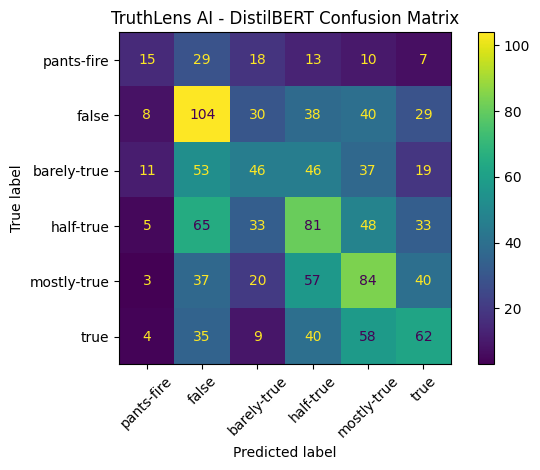

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    test_labels,
    test_predictions,
    display_labels=label_names,
    xticks_rotation=45
)

plt.title("TruthLens AI - DistilBERT Confusion Matrix")
plt.tight_layout()
plt.show()

In [22]:
MODEL_SAVE_PATH = "../models/distilbert_truthlens"

model.save_pretrained(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

print("DistilBERT model saved successfully.")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.13it/s]

DistilBERT model saved successfully.


In [23]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=label_names,
        zero_division=0
    )
)

              precision    recall  f1-score   support

  pants-fire       0.33      0.16      0.22        92
       false       0.32      0.42      0.36       249
 barely-true       0.29      0.22      0.25       212
   half-true       0.29      0.31      0.30       265
 mostly-true       0.30      0.35      0.32       241
        true       0.33      0.30      0.31       208

    accuracy                           0.31      1267
   macro avg       0.31      0.29      0.29      1267
weighted avg       0.31      0.31      0.30      1267



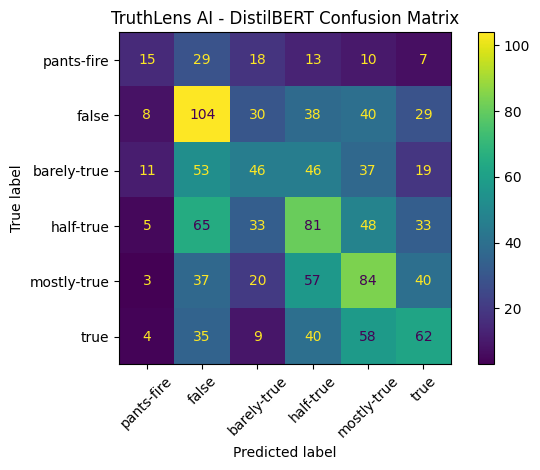

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    test_labels,
    test_predictions,
    display_labels=label_names,
    xticks_rotation=45
)

plt.title("TruthLens AI - DistilBERT Confusion Matrix")
plt.tight_layout()
plt.show()

In [25]:
MODEL_SAVE_PATH = "../models/distilbert_truthlens"

model.save_pretrained(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

print("DistilBERT model saved successfully.")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.27it/s]

DistilBERT model saved successfully.


In [26]:
from pathlib import Path

model_path = Path("../models/distilbert_truthlens")

print("Model folder exists:", model_path.exists())

if model_path.exists():
    print("\nSaved files:")
    for file in model_path.iterdir():
        print("-", file.name)

Model folder exists: True

Saved files:
- config.json
- model.safetensors
- tokenizer.json
- tokenizer_config.json
